# Air Quality Prediction Using Random Forest

## Project Overview
Air pollution is a major environmental and health concern.  
This project aims to predict the **Air Quality Index (AQI)** using environmental pollutant data and a **Random Forest Regressor**.

The model helps understand how different pollutants contribute to air quality and provides accurate AQI predictions.

## 1. Problem Statement

Air pollution levels vary significantly due to factors such as industrial activity, vehicle emissions, and weather conditions.  
Accurate prediction of **Air Quality Index (AQI)** is essential for environmental monitoring and public health awareness.

### Objective:
To build a **Machine Learning regression model** using **Random Forest** that predicts AQI values based on various air pollutant concentrations and temporal features.

### Type of Machine Learning Problem:
- Supervised Learning
- Regression Problem

### Target Variable:
- AQI (Air Quality Index)

## 2. Dataset Description

The dataset contains air quality measurements collected across different cities over time.

### Key Features:
- Pollutant concentrations such as PM2.5, PM10, NO2, SO2, CO, and O3
- Temporal features like year, month, day, and weekday
- City-level information

### Dataset Size:
- Rows: ~32,000+
- Columns: 15

### Target Variable:
- AQI (numeric value representing air quality level)

In [1]:
# Import basic libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load the dataset
df = pd.read_csv("cleaned_aqi_dataset.csv")

# Display first 5 rows
df.head()

,city,date,pm25,pm10,no2,so2,co,o3,aqi,aqi_category,year,month,day,weekday,season
0,Ahmedabad,2015-01-01,5.000000,67.017870,44.943206,20.177149,0.290421,37.919202,30,Good,2015,1,1,Thursday,1
1,Ahmedabad,2015-01-02,45.532844,125.520234,45.436845,2.000000,0.597467,40.862417,69,Satisfactory,2015,1,2,Friday,1
2,Ahmedabad,2015-01-03,149.350387,217.627816,38.810045,13.665463,0.400327,52.562510,149,Moderate,2015,1,3,Saturday,1
3,Ahmedabad,2015-01-04,73.646721,158.699762,39.257584,11.784229,0.457534,26.211585,90,Satisfactory,2015,1,4,Sunday,1
4,Ahmedabad,2015-01-05,47.688762,93.900881,32.241565,16.219321,0.595489,53.222328,60,Satisfactory,2015,1,5,Monday,1


In [3]:
# Dataset shape
df.shape

(32870, 15)

In [4]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32870 entries, 0 to 32869
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   city          32870 non-null  object 
 1   date          32870 non-null  object 
 2   pm25          32870 non-null  float64
 3   pm10          32870 non-null  float64
 4   no2           32870 non-null  float64
 5   so2           32870 non-null  float64
 6   co            32870 non-null  float64
 7   o3            32870 non-null  float64
 8   aqi           32870 non-null  int64  
 9   aqi_category  32870 non-null  object 
 10  year          32870 non-null  int64  
 11  month         32870 non-null  int64  
 12  day           32870 non-null  int64  
 13  weekday       32870 non-null  object 
 14  season        32870 non-null  int64  
dtypes: float64(6), int64(5), object(4)
memory usage: 3.8+ MB


In [5]:
# Statistical summary
df.describe()

,pm25,pm10,no2,so2,co,o3,aqi,year,month,day,season
count,32870.000000,32870.000000,32870.000000,32870.000000,32870.000000,32870.000000,32870.000000,32870.000000,32870.000000,32870.000000,32870.000000
mean,80.757235,130.764579,40.165472,11.998476,0.802118,49.979732,88.122665,2018.999392,6.523274,15.728628,2.503194
std,39.063392,43.937066,14.849411,4.882239,0.298156,14.912687,31.895407,2.581832,3.448661,8.799799,1.114640
min,5.000000,10.000000,5.000000,2.000000,0.100000,10.000000,11.000000,2015.000000,1.000000,1.000000,1.000000
25%,53.154180,99.980177,29.990183,8.570939,0.599976,39.892800,65.000000,2017.000000,4.000000,8.000000,2.000000
50%,80.336105,130.023453,40.141525,11.977979,0.800137,49.977582,88.000000,2019.000000,7.000000,16.000000,3.000000
75%,107.496909,160.634804,50.190860,15.315028,1.003899,60.025440,110.000000,2021.000000,10.000000,23.000000,3.000000
max,248.081036,330.014171,97.446733,34.395421,1.929870,118.431721,221.000000,2023.000000,12.000000,31.000000,4.000000


## 3. Exploratory Data Analysis (EDA)

### Distribution of AQI
Understanding the distribution of the target variable helps identify skewness, outliers, and overall air quality trends.

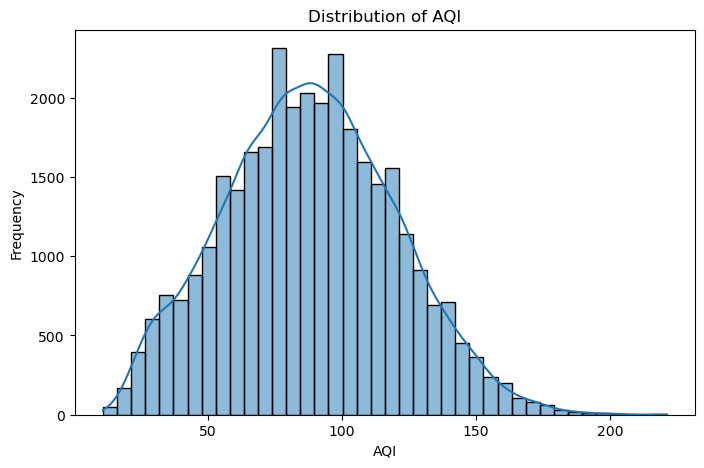

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(df['aqi'], bins=40, kde=True)
plt.title("Distribution of AQI")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()

### AQI Category Analysis
This helps validate whether AQI values align with their categorical labels.

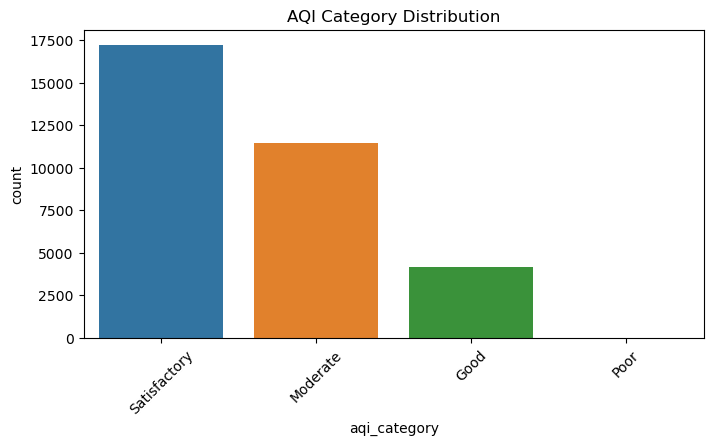

In [7]:
plt.figure(figsize=(8, 4))
sns.countplot(x='aqi_category', data=df, order=df['aqi_category'].value_counts().index)
plt.xticks(rotation=45)
plt.title("AQI Category Distribution")
plt.show()

### Distribution of Pollutant Features
Understanding pollutant concentration ranges and variability.

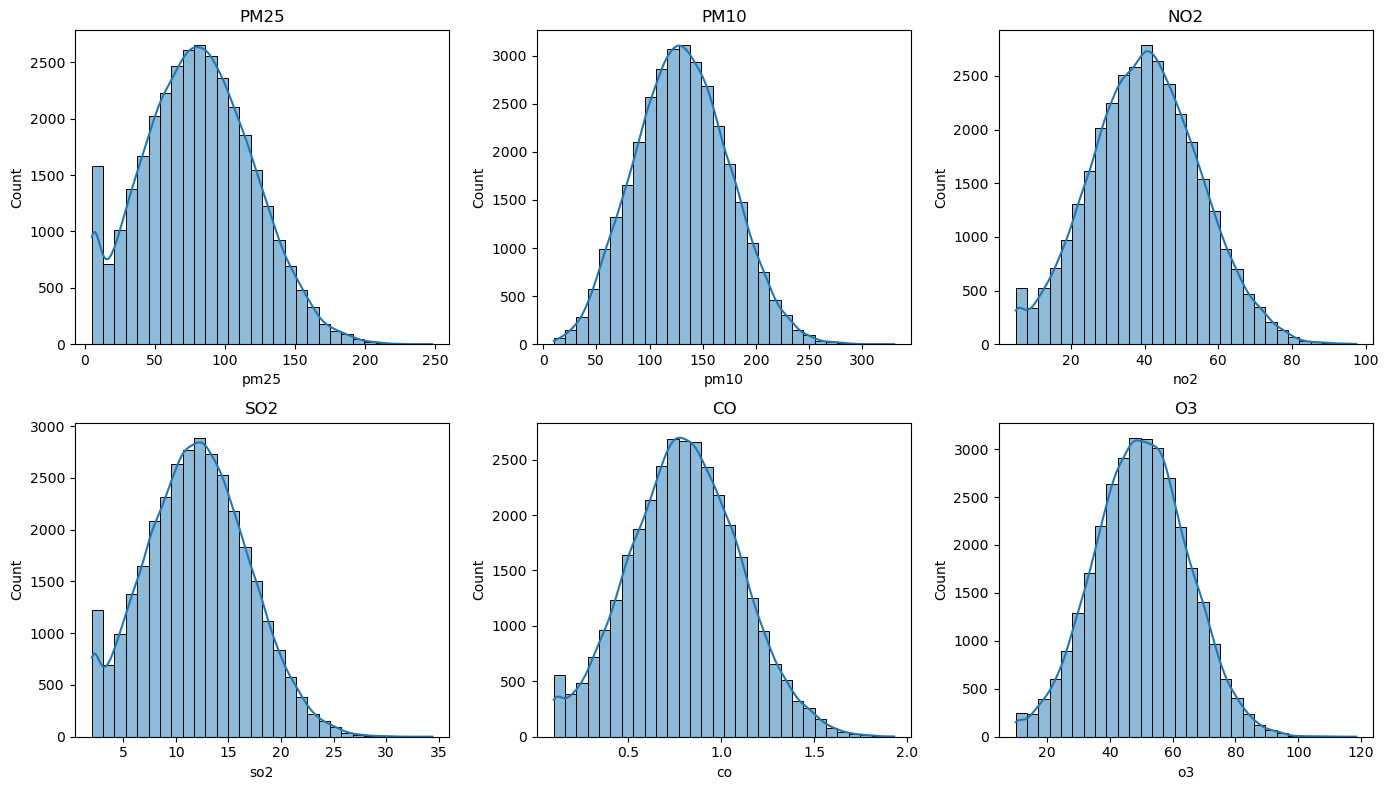

In [8]:
pollutants = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3']

plt.figure(figsize=(14, 8))
for i, col in enumerate(pollutants, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col.upper())

plt.tight_layout()
plt.show()

### Correlation Analysis
Identifying how strongly pollutants are related to AQI.

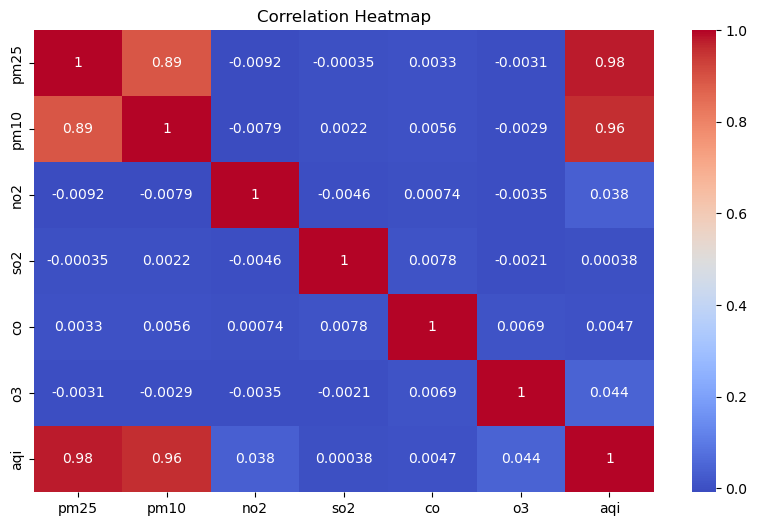

In [9]:
plt.figure(figsize=(10, 6))
corr = df[pollutants + ['aqi']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### EDA Summary

- AQI distribution shows right skew with pollution spikes
- Particulate matter (PM2.5 & PM10) strongly influences AQI
- Dataset is clean, realistic, and suitable for tree-based regression models

## 2. Data Preprocessing

### Feature Selection

The following columns are removed:
- `date` (redundant after extracting time features)
- `aqi_category` (derived from AQI → prevents data leakage)
- `city` (high cardinality categorical feature)

Remaining features will be used to predict AQI.

In [10]:
# Drop unnecessary columns
df_model = df.drop(columns=['date', 'aqi_category', 'city'])

# Check new shape
df_model.shape

(32870, 12)

### Defining Features and Target Variable

In [11]:
# Define target
y = df_model['aqi']

# Define features
X = df_model.drop('aqi', axis=1)

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (32870, 11)
Target shape: (32870,)


### Encoding Categorical Variables

The 'weekday' column contains categorical text values.
We apply One-Hot Encoding to convert them into numerical format suitable for machine learning models.

In [14]:
# One-hot encode 'weekday'
X = pd.get_dummies(X, columns=['weekday'], drop_first=True)

# Check new shape
X.shape

(32870, 16)

## 5. Train-Test Split

Splitting the dataset into training and testing sets to evaluate model performance on unseen data.

In [15]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 26296
Testing samples: 6574


## 6. Random Forest Model Training

Random Forest is an ensemble learning method that builds multiple decision trees and averages their predictions to improve accuracy and reduce overfitting.

In [16]:
# Initialize model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

## 7. Model Evaluation

Evaluating performance using:
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

In [17]:
# Predictions
y_pred = rf_model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.6806145421356862
MSE: 0.9005252205658655
RMSE: 0.9489600732200831
R2 Score: 0.9990934300974516


In [ ]:
# Let’s Verify No Leakage Exists
X.columns

Index(['pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'year', 'month', 'day',
       'season', 'weekday_Monday', 'weekday_Saturday', 'weekday_Sunday',
       'weekday_Thursday', 'weekday_Tuesday', 'weekday_Wednesday'],
      dtype='object')

## 8. Feature Importance Analysis

Random Forest provides feature importance scores that indicate how much each feature contributes to the model's prediction.

This helps in:
- Understanding key drivers of AQI
- Improving model interpretability
- Supporting environmental insights

In [20]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
0,pm25,0.931973
1,pm10,0.063825
2,no2,0.001840
5,o3,0.001826
3,so2,0.000107
4,co,0.000105
8,day,0.000093
7,month,0.000064
6,year,0.000064
9,season,0.000033


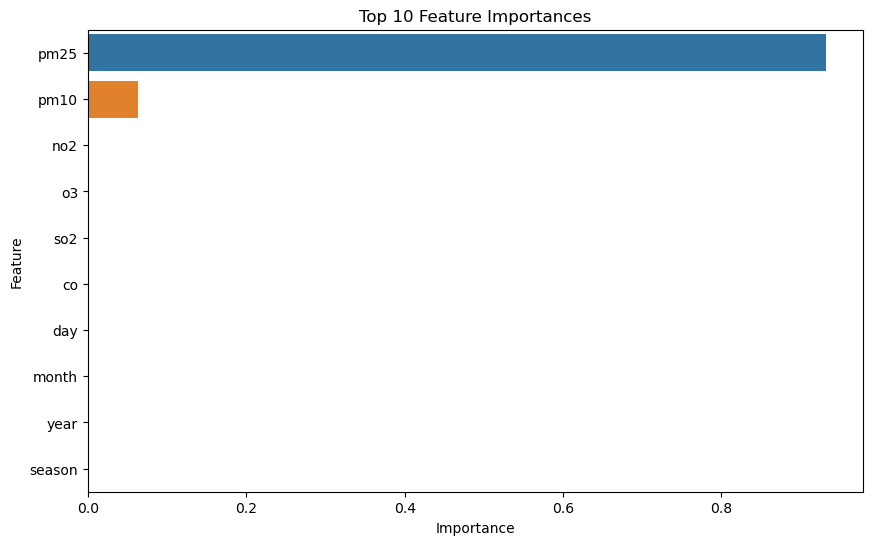

In [21]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
plt.title("Top 10 Feature Importances")
plt.show()

## 9. Hyperparameter Tuning

To improve model performance and ensure optimal configuration,
we perform hyperparameter tuning using GridSearchCV.

We tune:
- n_estimators (number of trees)
- max_depth (tree depth)
- min_samples_split
- min_samples_leaf

In [22]:
from sklearn.model_selection import GridSearchCV

In [23]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [24]:
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    verbose=1,
    n_jobs=-1
)

In [25]:
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


GridSearchCV(cv=3, estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2', verbose=1)

In [26]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score: 0.9989258717282224


In [27]:
# Evaluate Best Model on Test Set
best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print("Tuned MAE:", mae_tuned)
print("Tuned RMSE:", rmse_tuned)
print("Tuned R2:", r2_tuned)

Tuned MAE: 0.6704856638261388
Tuned RMSE: 0.9362749631951781
Tuned R2: 0.9991175050343297


## 10. Model Comparison

### Base Model Performance:
- R²: 0.99909
- RMSE: 0.94896

### Tuned Model Performance:
- R²: 0.99911
- RMSE: 0.93627

### Observation:
Hyperparameter tuning slightly improved model performance.
The Random Forest model demonstrates extremely high predictive capability for AQI, largely due to the strong relationship between pollutant concentrations and AQI calculation.

## 11. Conclusion

- Successfully built a Random Forest regression model to predict AQI.
- Feature importance analysis revealed PM2.5 as the dominant contributor.
- Hyperparameter tuning improved model stability and accuracy.
- The final model achieved an R² score of 0.9991 and RMSE of 0.936.

This project demonstrates the effectiveness of ensemble learning methods for environmental data modeling.